# Visão geral

Este notebook apresenta uma análise de uma base de filmes com foco em informações como gênero, direção, palavras-chave, avaliações e desempenho financeiro.

O fluxo do estudo segue uma sequência simples: primeiro os dados são carregados e organizados, depois a base principal é tratada, em seguida as informações complementares são incorporadas e, por fim, são geradas tabelas e gráficos para apoiar a leitura dos resultados.

As células abaixo explicam apenas o que cada etapa mostra e como ler o resultado exibido em cada uma delas.


## Preparação da análise

In [4]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'codigo' / 'pipeline_filmes.py').is_file():
            return candidate
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')


def safe_int(value):
    return int(value) if pd.notna(value) else None


PROJECT_ROOT = resolve_project_root()
CODIGO_DIR = PROJECT_ROOT / 'codigo'
if str(CODIGO_DIR) not in sys.path:
    sys.path.insert(0, str(CODIGO_DIR))

from pipeline_filmes import (
    build_aggregations,
    build_directors,
    build_gold_dataset,
    build_keywords,
    build_movie_ratings,
    clean_movies,
    load_raw_datasets,
    plot_results,
    save_outputs,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 120)


## Carregamento das bases

In [5]:
loaded = load_raw_datasets(PROJECT_ROOT)
processed_dir = loaded['processed_dir']
raw_movies_df = loaded['tables']['movies']

pd.Series(
    {
        'base_dir': str(loaded['base_dir']),
        'raw_dir': str(loaded['raw_dir']),
        'processed_dir': str(processed_dir),
    }
).to_frame('caminho')


Ingestao concluida!
  movies    45466 linhas, 24 colunas
  credits   45476 linhas, 3 colunas
  keywords  46419 linhas, 2 colunas
  links     45843 linhas, 3 colunas
  ratings  100004 linhas, 4 colunas


,caminho
base_dir,/content
raw_dir,/content/dados/raw
processed_dir,/content/dados/processed


## Tamanho das tabelas

In [6]:
pd.DataFrame(
    {name: df.shape for name, df in loaded['tables'].items()},
    index=['linhas', 'colunas'],
).T


,linhas,colunas
movies,45466,24
credits,45476,3
keywords,46419,2
links,45843,3
ratings,100004,4


## Limpeza da base de filmes

Aplica-se o tratamento na base principal de filmes e exibe uma amostra do resultado. O que aparece aqui já corresponde a uma versão mais organizada e adequada para análise.

In [7]:
clean_movies_df = clean_movies(raw_movies_df)
clean_movies_df.head(10)


Total de linhas em movies_metadata: 45466
Linhas removidas por ID invalido: 3
Linhas removidas por ID duplicado: 30
Linhas apos limpeza principal: 43608


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/...",30000000.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afrai...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwitting...",17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications'...","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_pat...",NaN,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile,...",11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,NaN,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to bre...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,"[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop...",NaN,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and t...",8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}, {'name': 'Touchstone Pictures', 'id': 9195}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's In For The Surprise Of His Life!,Father of the Bride Part II,False,5.7,173.0
5,False,NaN,60000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'name': 'Crime'}, {'id': 18, 'name': 'Drama'}, {'id': 53, 'name': 'Thrille...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a top-notch crew on various insane heists th

## Comparação entre antes e depois da limpeza

Comparação de tamanho da base original com o tamanho da base tratada.

In [8]:
pd.DataFrame(
    {'raw': raw_movies_df.shape, 'clean': clean_movies_df.shape},
    index=['linhas', 'colunas'],
).T


,linhas,colunas
raw,45466,24
clean,43608,24


## Comparação de valores ausentes

Compara a quantidade de valores ausentes antes e depois da limpeza.

In [9]:
shared_columns = raw_movies_df.columns.intersection(clean_movies_df.columns)
pd.DataFrame(
    {
        'raw': raw_movies_df[shared_columns].isna().sum(),
        'clean': clean_movies_df[shared_columns].isna().sum(),
    }
).query('raw > 0 or clean > 0').sort_values(['raw', 'clean'], ascending=False)


,raw,clean
belongs_to_collection,40972,39215
homepage,37684,35936
tagline,25054,23349
overview,954,290
poster_path,386,262
runtime,263,0
status,87,60
release_date,87,50
imdb_id,17,11
original_language,11,10


## Tabela de diretores

Tabela com a identificação dos diretores de cada filme e exibe uma amostra.

In [10]:
directors_df = build_directors(loaded['tables']['credits'])
directors_df.head(10)


,id,director
0,862,John Lasseter
1,8844,Joe Johnston
2,15602,Howard Deutch
3,31357,Forest Whitaker
4,11862,Charles Shyer
5,949,Michael Mann
6,11860,Sydney Pollack
7,45325,Peter Hewitt
8,9091,Peter Hyams
9,710,Martin Campbell


## Tabela de palavras-chave

In [11]:
keywords_df = build_keywords(loaded['tables']['keywords'])
keywords_df.head(10)


,id,keywords_list,primary_keyword,keyword_count
0,862,"[jealousy, toy, boy, friendship, friends, rivalry, boy next door, new toy, toy comes to life]",jealousy,9
1,8844,"[board game, disappearance, based on children's book, new home, recluse, giant insect]",board game,6
2,15602,"[fishing, best friend, duringcreditsstinger, old men]",fishing,4
3,31357,"[based on novel, interracial relationship, single mother, divorce, chick flick]",based on novel,5
4,11862,"[baby, midlife crisis, confidence, aging, daughter, mother daughter relationship, pregnancy, contraception, gynecolo...",baby,9
5,949,"[robbery, detective, bank, obsession, chase, shooting, thief, honor, murder, suspense, heist, betrayal, money, gang,...",robbery,25
6,11860,"[paris, brother brother relationship, chauffeur, long island, fusion, millionaire]",paris,6
7,45325,[],None,0
8,9091,"[terrorist, hostage, explosive, vice president]",terrorist,4
9,710,"[cuba, falsely accused, secret identity, computer virus, secret base, secret intelligence service, kgb, satellite, s...",cuba,15


## Avaliações dos usuários

In [12]:
movie_ratings_df = build_movie_ratings(loaded['tables']['links'], loaded['tables']['ratings'])
movie_ratings_df.head(10)


,id,user_rating_avg,user_rating_count
0,2,4.50,1
1,5,3.29,26
2,6,3.25,4
3,11,4.22,291
4,12,3.80,122
5,13,4.05,341
6,14,4.24,220
7,15,4.20,85
8,16,3.80,23
9,18,3.68,118


## Base analítica final

Reúne em uma única tabela os dados principais dos filmes, além das informações de direção, palavras-chave e avaliações.

In [13]:
gold_df = build_gold_dataset(clean_movies_df, directors_df, keywords_df, movie_ratings_df)
gold_df.head(10)


,id,title,primary_genre,genres_list,director,primary_keyword,keywords_list,keyword_count,budget,revenue,profit,roi,vote_average,vote_count,user_rating_avg,user_rating_count,popularity,runtime,original_language,release_date,release_year,decade,has_collection,overview,status
0,862,Toy Story,Animation,"[Animation, Comedy, Family]",John Lasseter,jealousy,"[jealousy, toy, boy, friendship, friends, rivalry, boy next door, new toy, toy comes to life]",9,30000000.0,373554033.0,343554033.0,1145.18,7.7,5415.0,3.87,247.0,21.946943,81.0,en,1995-10-30,1995,1990,1,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afrai...",Released
1,8844,Jumanji,Adventure,"[Adventure, Fantasy, Family]",Joe Johnston,board game,"[board game, disappearance, based on children's book, new home, recluse, giant insect]",6,65000000.0,262797249.0,197797249.0,304.30,6.9,2413.0,3.40,107.0,17.015539,104.0,en,1995-12-15,1995,1990,0,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwitting...",Released
2,15602,Grumpier Old Men,Romance,"[Romance, Comedy]",Howard Deutch,fishing,"[fishing, best friend, duringcreditsstinger, old men]",4,NaN,NaN,NaN,NaN,6.5,92.0,3.16,59.0,11.712900,101.0,en,1995-12-22,1995,1990,1,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile,...",Released
3,31357,Waiting to Exhale,Comedy,"[Comedy, Drama, Romance]",Forest Whitaker,based on novel,"[based on novel, interracial relationship, single mother, divorce, chick flick]",5,16000000.0,81452156.0,65452156.0,409.08,6.1,34.0,2.38,13.0,3.859495,127.0,en,1995-12-22,1995,1990,0,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to bre...",Released
4,11862,Father of the Bride Part II,Comedy,[Comedy],Charles Shyer,baby,"[baby, midlife crisis, confidence, aging, daughter, mother daughter relationship, pregnancy, contraception, gynecolo...",9,NaN,76578911.0,NaN,NaN,5.7,173.0,3.27,56.0,8.387519,106.0,en,1995-02-10,1995,1990,1,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and t...",Released
5,949,Heat,Action,"[Action, Crime, Drama, Thriller]",Michael Mann,robbery,"[robbery, detective, bank, obsession, chase, shooting, thief, honor, murder, suspense, heist, betrayal, money, gang,...",25,60000000.0,187436818.0,127436818.0,212.39,7.7,1886.0,3.88,104.0,17.924927,170.0,en,1995-12-15,1995,1990,0,"Obsessive master thief, Neil McCauley leads a top-notch crew on various insane heists throughout Los Angeles while a...",Released
6,11860,Sabrina,Comedy,"[Comedy, Romance]",Sydney Pollack,paris,"[paris, brother brother relationship, chauffeur, long island, fusion, millionaire]",6,58000000.0,NaN,NaN,NaN,6.2,141.0,3.28,53.0,6.677277,127.0,en,1995-12-15,1995,1990,0,"An ugly duckling having undergone a remarkable change, still harbors feelings for her crush: a carefree playboy, but...",Released
7,45325,Tom and Huck,Action,"[Action, Adventure, Drama, Family]",Peter Hewitt,None,[],0,NaN,NaN,NaN,NaN,5.4,45.0,3.80,5.0,2.561161,97.0,en,1995-12-22,1995,1990,0,"A mischievous young boy, Tom Sawyer, witnesses a murder by the deadly Injun Joe. Tom becomes friends with Huckleberr...",Released
8,9091,Sudden Death,Action,"[Action, Adventure, Thriller]",Peter Hyams,terrorist,"[terrorist, hostage, explosive, vice president]",4,35000000.0,64350171.0,29350171.0,83.86,5.5,174.0,3.15,20.0,5.231580,106.0,en,1995-12-22,1995,1990,0,"International action superstar Jean Claude Van Damme teams with Powers Boothe in a Tension-packed, suspense thriller...",Released
9,710,GoldenEye,Adventure,"[Adventure, Action, Thriller]",Martin Campbell,cuba,"[cuba, falsely accused, secret identity, computer virus, secret base, secret intelligence service, kgb, satellite, s...",15,58000000.0,352194034.0,294194034.0,507.23,6.6,1194.0,3.45,122.0,14.686036,130.0,en

## Tipos das colunas

Esta célula mostra o tipo de cada coluna da base final. O resultado serve como conferência da estrutura dos dados antes das etapas de resumo e visualização.

In [14]:
gold_df.dtypes.to_frame('tipo')


,tipo
id,int64
title,object
primary_genre,object
genres_list,object
director,object
primary_keyword,object
keywords_list,object
keyword_count,int64
budget,float64
revenue,float64


## Estatísticas numéricas

Esta célula apresenta estatísticas descritivas das colunas numéricas da base final.

In [15]:
gold_df.select_dtypes(include='number').describe().T


,count,mean,std,min,25%,50%,75%,max
id,43608.0,105079.162378,110863.358969,2.0,25507.75,57090.0,147685.25,469172.0
keyword_count,43608.0,3.563452,4.738499,0.0,0.0,2.0,5.0,149.0
budget,8808.0,21768180.9698,34421530.045303,1.0,2000000.0,8500000.0,25000000.0,380000000.0
revenue,7371.0,69083717.099579,146721663.73757,1.0,2414411.5,16942795.0,67764103.5,2787965087.0
profit,5363.0,59416977.55771,139727916.497752,-165710090.0,-1474409.5,11182492.0,62641932.5,2550965087.0
roi,5363.0,558357.508314,21722008.339435,-100.0,-21.08,106.19,325.29,1239638200.0
vote_average,43608.0,5.67228,1.855651,0.0,5.0,6.0,6.8,10.0
vote_count,43608.0,114.255939,501.151091,0.0,4.0,10.0,36.0,14075.0
user_rating_avg,9005.0,3.289775,0.881752,0.5,2.83,3.5,3.96,5.0
user_rating_count,9005.0,11.081288,24.117642,1.0,1.0,3.0,9.0,341.0


## Exemplo de comparação entre registro original e final

Esta célula coloca lado a lado um exemplo de filme na forma original e na forma final usada na análise.

In [16]:
sample_candidates = gold_df.loc[
    gold_df['director'].notna() & gold_df['primary_keyword'].notna() & gold_df['user_rating_avg'].notna(),
    'id',
]
sample_movie_id = sample_candidates.iloc[0] if not sample_candidates.empty else gold_df['id'].iloc[0]

raw_sample_source = raw_movies_df.copy()
raw_sample_source['id_numeric'] = pd.to_numeric(raw_sample_source['id'], errors='coerce')
raw_sample = raw_sample_source.loc[raw_sample_source['id_numeric'].eq(sample_movie_id)].drop(columns=['id_numeric']).iloc[0]
gold_sample = gold_df.loc[gold_df['id'].eq(sample_movie_id)].iloc[0]

pd.concat(
    [raw_sample.rename('raw'), gold_sample.rename('gold')],
    axis=1,
)


,raw,gold
adult,False,NaN
belongs_to_collection,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/...",NaN
budget,30000000,30000000.0
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",NaN
homepage,http://toystory.disney.com/toy-story,NaN
id,862,862
imdb_id,tt0114709,NaN
original_language,en,en
original_title,Toy Story,NaN
overview,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afrai...","Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afrai..."


## Tabelas agregadas

Esta célula gera as tabelas-resumo da análise e mostra quantas linhas existem em cada uma delas.

In [17]:
tables = build_aggregations(gold_df)
pd.Series({name: len(df) for name, df in tables.items()}).to_frame('linhas')


,linhas
receita_por_genero,20
top_diretores,795
filmes_por_decada,15
top_palavras_chave,2890
correlacoes_sucesso,12
top_filmes_receita,20
top_filmes_roi,20
resumo_sucesso_por_genero,18
resumo_sucesso_por_diretor,795
resumo_sucesso_por_decada,10


## Prévia dos principais resultados

Esta célula exibe uma amostra das tabelas agregadas mais importantes.

In [18]:
table_previews = [
    'receita_por_genero',
    'top_diretores',
    'filmes_por_decada',
    'top_palavras_chave',
    'correlacoes_sucesso',
    'top_filmes_receita',
    'top_filmes_roi',
]

for name in table_previews:
    print(f'=== {name} ===')
    display(tables[name].head(10))


=== receita_por_genero ===


,primary_genre,receita_total_bi,receita_media_mi,qtd_filmes
0,Action,122.04,102.30,1193
1,Adventure,84.13,177.49,474
3,Comedy,75.77,48.63,1558
6,Drama,72.53,37.60,1929
2,Animation,35.85,190.70,188
8,Fantasy,19.48,107.64,181
15,Science Fiction,17.34,149.51,116
11,Horror,17.09,42.40,403
17,Thriller,15.35,59.26,259
7,Family,13.68,173.14,79


=== top_diretores ===


,director,receita_total_bi,nota_metadata_media,nota_usuarios_media,qtd_filmes
0,Steven Spielberg,9.26,6.94,3.53,30
1,Peter Jackson,6.53,7.27,3.55,11
2,Michael Bay,6.44,6.39,2.99,13
3,James Cameron,5.90,7.31,3.71,8
4,David Yates,5.33,7.15,3.69,6
5,Christopher Nolan,4.75,7.72,3.91,10
6,Robert Zemeckis,4.14,6.86,3.36,17
7,Tim Burton,4.03,6.73,3.32,18
8,Ridley Scott,3.92,6.58,3.30,23
9,Chris Columbus,3.87,6.46,3.14,13


=== filmes_por_decada ===


...

,target,feature,correlation,sample_size
0,revenue,vote_count,0.7816,7371
1,revenue,budget,0.7301,5363
2,revenue,popularity,0.4576,7371
3,revenue,runtime,0.2043,7371
4,revenue,vote_average,0.1489,7371
5,revenue,user_rating_avg,0.0011,4737
6,roi,vote_average,0.0156,5363
7,roi,user_rating_avg,0.0062,3830
8,roi,popularity,-0.0087,5363
9,roi,vote_count,-0.0087,5363


=== top_filmes_receita ===


,title,release_year,primary_genre,director,revenue,budget,profit,roi,vote_average,user_rating_avg,vote_count,user_rating_count
0,Avatar,2009,Action,James Cameron,2.787965e+09,237000000.0,2.550965e+09,1076.36,7.2,3.64,12114.0,67.0
1,Star Wars: The Force Awakens,2015,Action,J.J. Abrams,2.068224e+09,245000000.0,1.823224e+09,744.17,7.5,3.52,7993.0,29.0
2,Titanic,1997,Drama,James Cameron,1.845034e+09,200000000.0,1.645034e+09,822.52,7.5,3.33,7770.0,164.0
3,The Avengers,2012,Science Fiction,Joss Whedon,1.519558e+09,220000000.0,1.299558e+09,590.71,7.4,4.01,12000.0,46.0
4,Jurassic World,2015,Action,Colin Trevorrow,1.513529e+09,150000000.0,1.363529e+09,909.02,6.5,3.44,8842.0,9.0
5,Furious 7,2015,Action,James Wan,1.506249e+09,190000000.0,1.316249e+09,692.76,7.3,2.25,4253.0,2.0
6,Avengers: Age of Ultron,2015,Action,Joss Whedon,1.405404e+09,280000000.0,1.125404e+09,401.93,7.3,3.88,6908.0,13.0
7,Harry Potter and the Deathly Hallows: Part 2,2011,Family,David Yates,1.342000e+09,125000000.0,1.217000e+09,973.60,7.9,4.22,6141.0,34.0
8,Frozen,2013,Animation,Chris Buck,1.274219e+09,150000000.0,1.124219e+09,749.48,7.3,4.04,5440.0,12.0
9,Beauty and the Beast,2017,Family,Bill Condon,1.262886e+09,160000000.0,1.102886e+09,689.30,6.8,NaN,5530.0,NaN


=== top_filmes_roi ===


,title,release_year,primary_genre,director,revenue,budget,profit,roi,vote_average,user_rating_avg,vote_count,user_rating_count
0,Alice in Wonderland,1951,Animation,Hamilton Luske,572000000.0,3000000.0,569000000.0,18966.67,7.0,3.61,1557.0,49.0
1,Snow White and the Seven Dwarfs,1937,Fantasy,David Hand,184925486.0,1488423.0,183437063.0,12324.26,6.9,3.66,1973.0,71.0
2,Rocky,1976,Drama,John G. Avildsen,117235147.0,1000000.0,116235147.0,11623.51,7.5,3.79,1843.0,69.0
3,The Devil Inside,2012,Thriller,William Brent Bell,101758490.0,1000000.0,100758490.0,10075.85,4.6,NaN,263.0,NaN
4,Gone with the Wind,1939,Drama,Victor Fleming,400176459.0,4000000.0,396176459.0,9904.41,7.7,4.04,995.0,68.0
5,The Rocky Horror Picture Show,1975,Comedy,Jim Sharman,112892319.0,1200000.0,111692319.0,9307.69,7.4,3.17,703.0,63.0
6,Cinderella,1950,Family,Clyde Geronimi,263591415.0,2900000.0,260691415.0,8989.36,6.8,3.56,1760.0,55.0
7,Saw,2004,Horror,James Wan,103911669.0,1200000.0,102711669.0,8559.31,7.2,3.27,2255.0,33.0
8,E.T. the Extra-Terrestrial,1982,Science Fiction,Steven Spielberg,792965326.0,10500000.0,782465326.0,7452.05,7.3,3.77,3359.0,160.0
9,My Big Fat Greek Wedding,2002,Comedy,Joel Zwick,368744044.0,5000000.0,363744044.0,7274.88,6.2,3.36,686.0,51.0


## Salvamento dos resultados

In [19]:
output_paths = save_outputs(processed_dir, gold_df, tables)
pd.Series({name: str(path) for name, path in output_paths.items()}).to_frame('caminho')


Dataset final salvo em CSV: /content/dados/processed/filmes_processados.csv
Dataset final salvo em Parquet: /content/dados/processed/filmes_processados_parquet
Tabela salva: /content/dados/processed/receita_por_genero.csv
Tabela salva: /content/dados/processed/top_diretores.csv
Tabela salva: /content/dados/processed/filmes_por_decada.csv
Tabela salva: /content/dados/processed/top_palavras_chave.csv
Tabela salva: /content/dados/processed/correlacoes_sucesso.csv
Tabela salva: /content/dados/processed/top_filmes_receita.csv
Tabela salva: /content/dados/processed/top_filmes_roi.csv
Tabela salva: /content/dados/processed/resumo_sucesso_por_genero.csv
Tabela salva: /content/dados/processed/resumo_sucesso_por_diretor.csv
Tabela salva: /content/dados/processed/resumo_sucesso_por_decada.csv
Tabela salva: /content/dados/processed/resumo_sucesso_por_palavra_chave.csv


,caminho
filmes_processados_csv,/content/dados/processed/filmes_processados.csv
filmes_processados_parquet,/content/dados/processed/filmes_processados_parquet
receita_por_genero,/content/dados/processed/receita_por_genero.csv
top_diretores,/content/dados/processed/top_diretores.csv
filmes_por_decada,/content/dados/processed/filmes_por_decada.csv
top_palavras_chave,/content/dados/processed/top_palavras_chave.csv
correlacoes_sucesso,/content/dados/processed/correlacoes_sucesso.csv
top_filmes_receita,/content/dados/processed/top_filmes_receita.csv
top_filmes_roi,/content/dados/processed/top_filmes_roi.csv
resumo_sucesso_por_genero,/content/dados/processed/resumo_sucesso_por_genero.csv


## Geração dos gráficos

Esta célula cria os gráficos usados no notebook e mostra onde eles foram salvos. O resultado indica quais visualizações foram produzidas.

In [20]:
plot_paths = plot_results(processed_dir, gold_df, tables)
pd.Series({name: str(path) for name, path in plot_paths.items()}).to_frame('caminho')


Graficos salvos em: /content/dados/processed/visualizacoes


,caminho
receita_por_genero,/content/dados/processed/visualizacoes/receita_por_genero.png
filmes_por_decada,/content/dados/processed/visualizacoes/filmes_por_decada.png
orcamento_vs_receita,/content/dados/processed/visualizacoes/orcamento_vs_receita.png
correlacoes_sucesso,/content/dados/processed/visualizacoes/correlacoes_sucesso.png


## Arquivos CSV gerados

Esta célula lista os arquivos CSV produzidos e seus tamanhos. O resultado funciona como uma conferência simples das saídas exportadas pela análise.

In [21]:
pd.DataFrame(
    [(path.name, path.stat().st_size) for path in processed_dir.glob('*.csv')],
    columns=['arquivo', 'bytes'],
).sort_values('bytes', ascending=False).reset_index(drop=True)


,arquivo,bytes
0,filmes_processados.csv,22965994
1,top_palavras_chave.csv,71848
2,resumo_sucesso_por_palavra_chave.csv,53890
3,resumo_sucesso_por_diretor.csv,38979
4,top_diretores.csv,24265
5,top_filmes_receita.csv,2340
6,top_filmes_roi.csv,2221
7,resumo_sucesso_por_genero.csv,978
8,resumo_sucesso_por_decada.csv,562
9,receita_por_genero.csv,526


## Resumo final e gráficos

Esta célula mostra um pequeno resumo com alguns destaques extraídos das tabelas e, em seguida, exibe os gráficos gerados.

,genero_lider_receita,diretor_lider_receita,decada_com_mais_filmes
0,Action,Steven Spielberg,2010


=== receita_por_genero ===


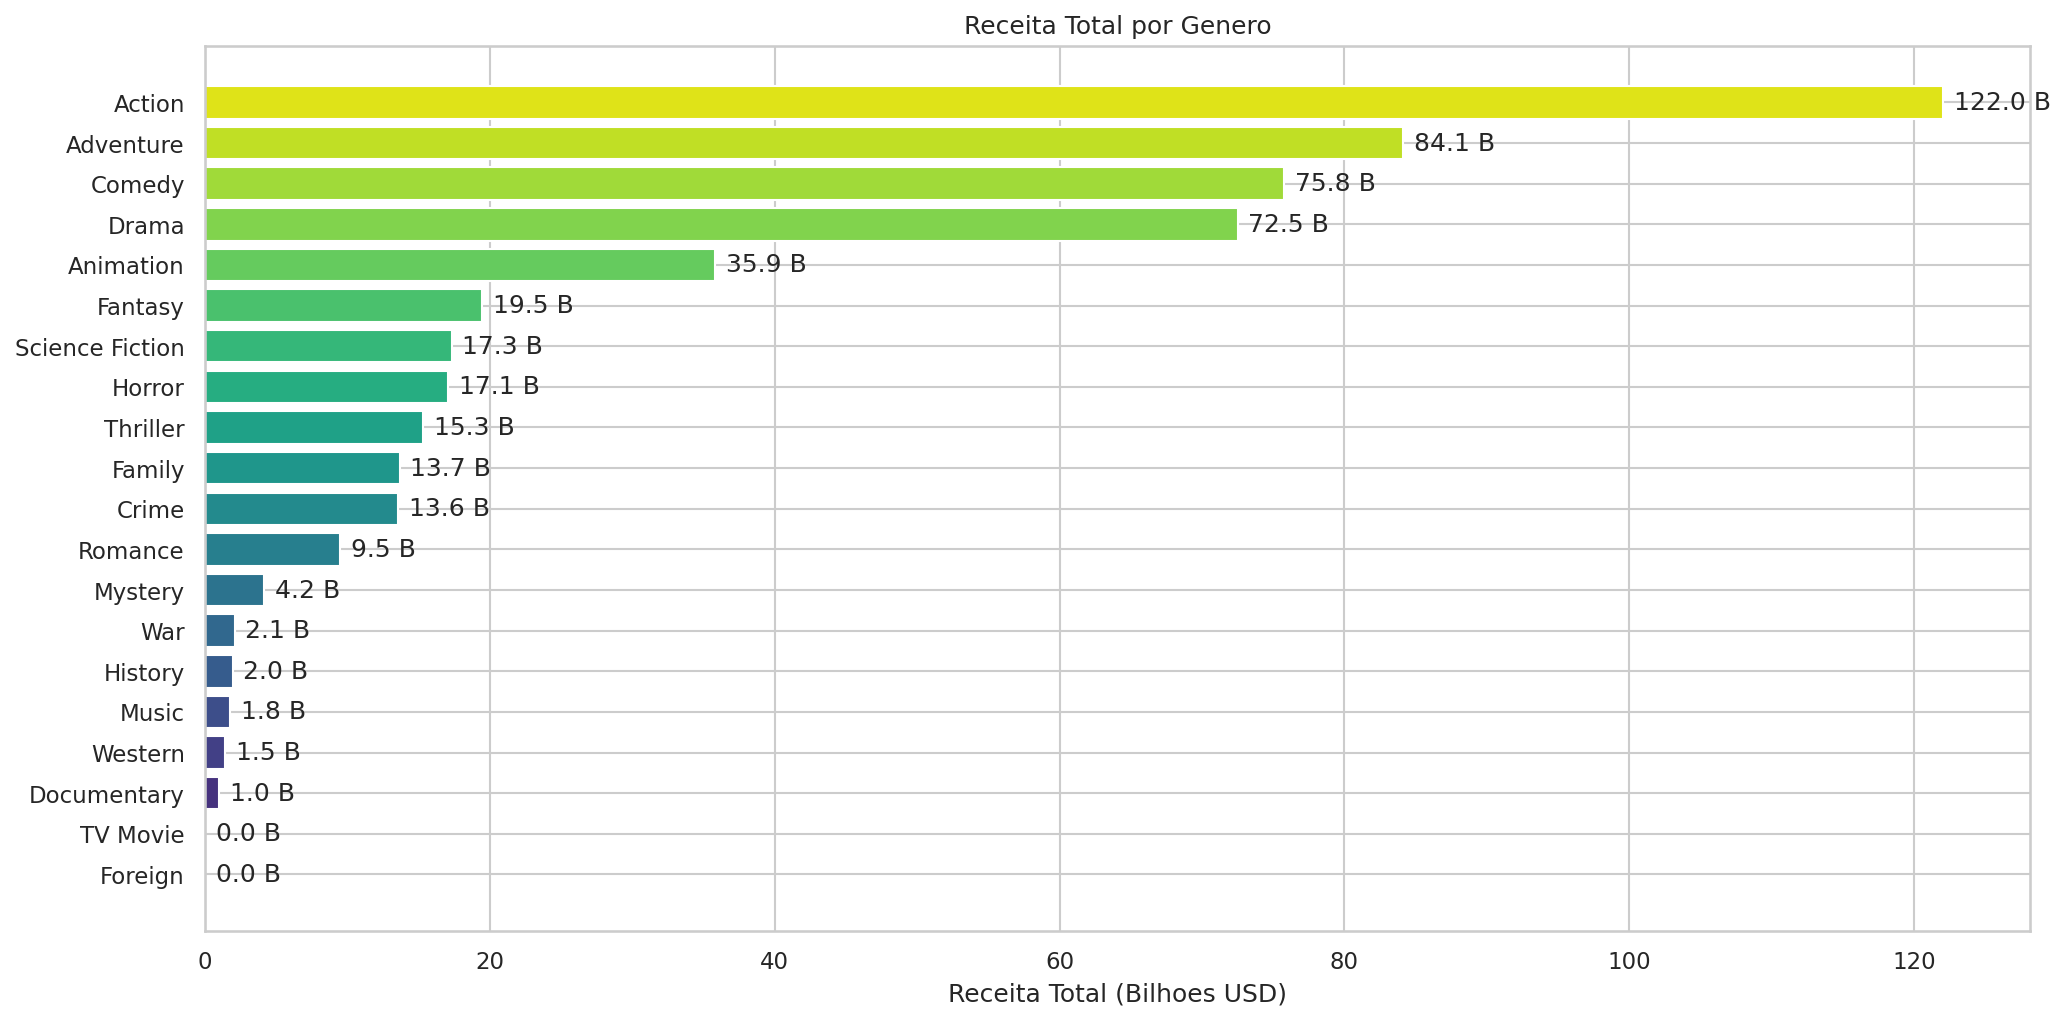

=== filmes_por_decada ===


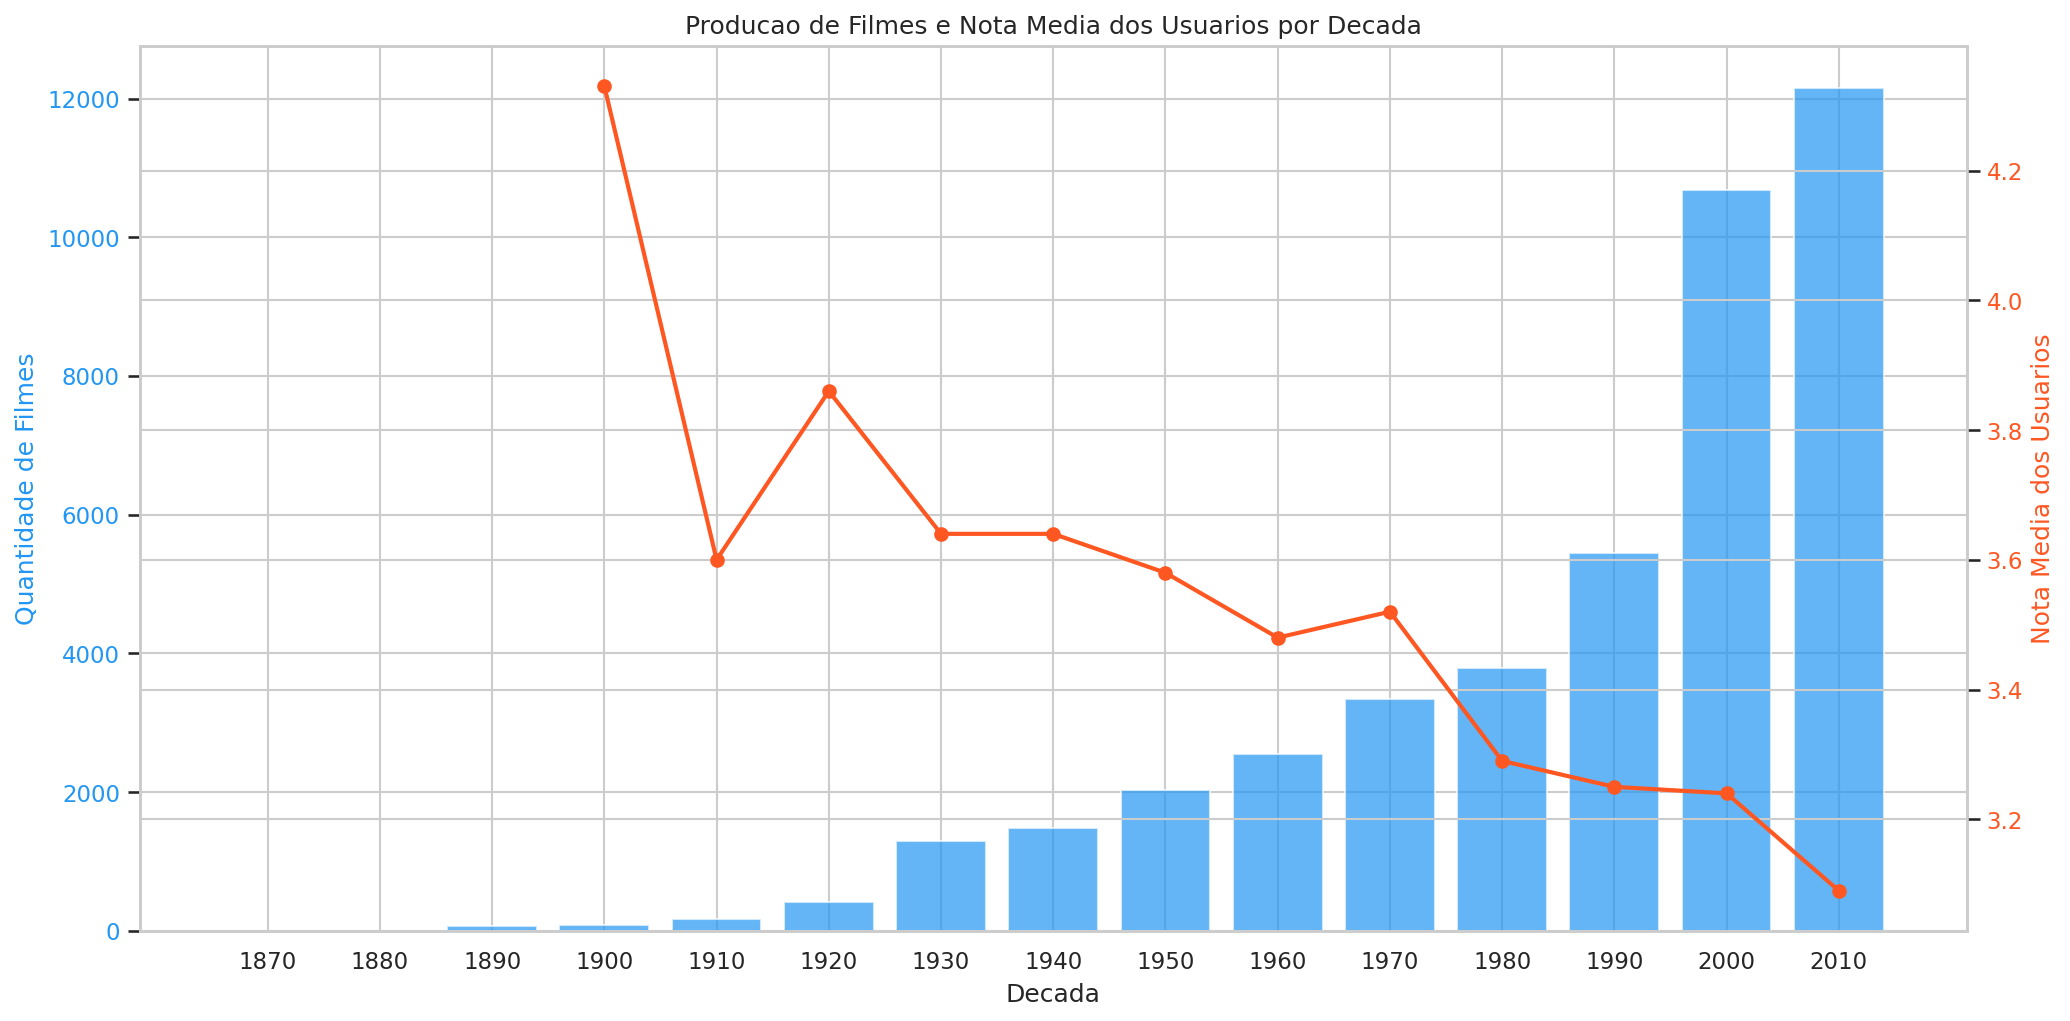

=== orcamento_vs_receita ===


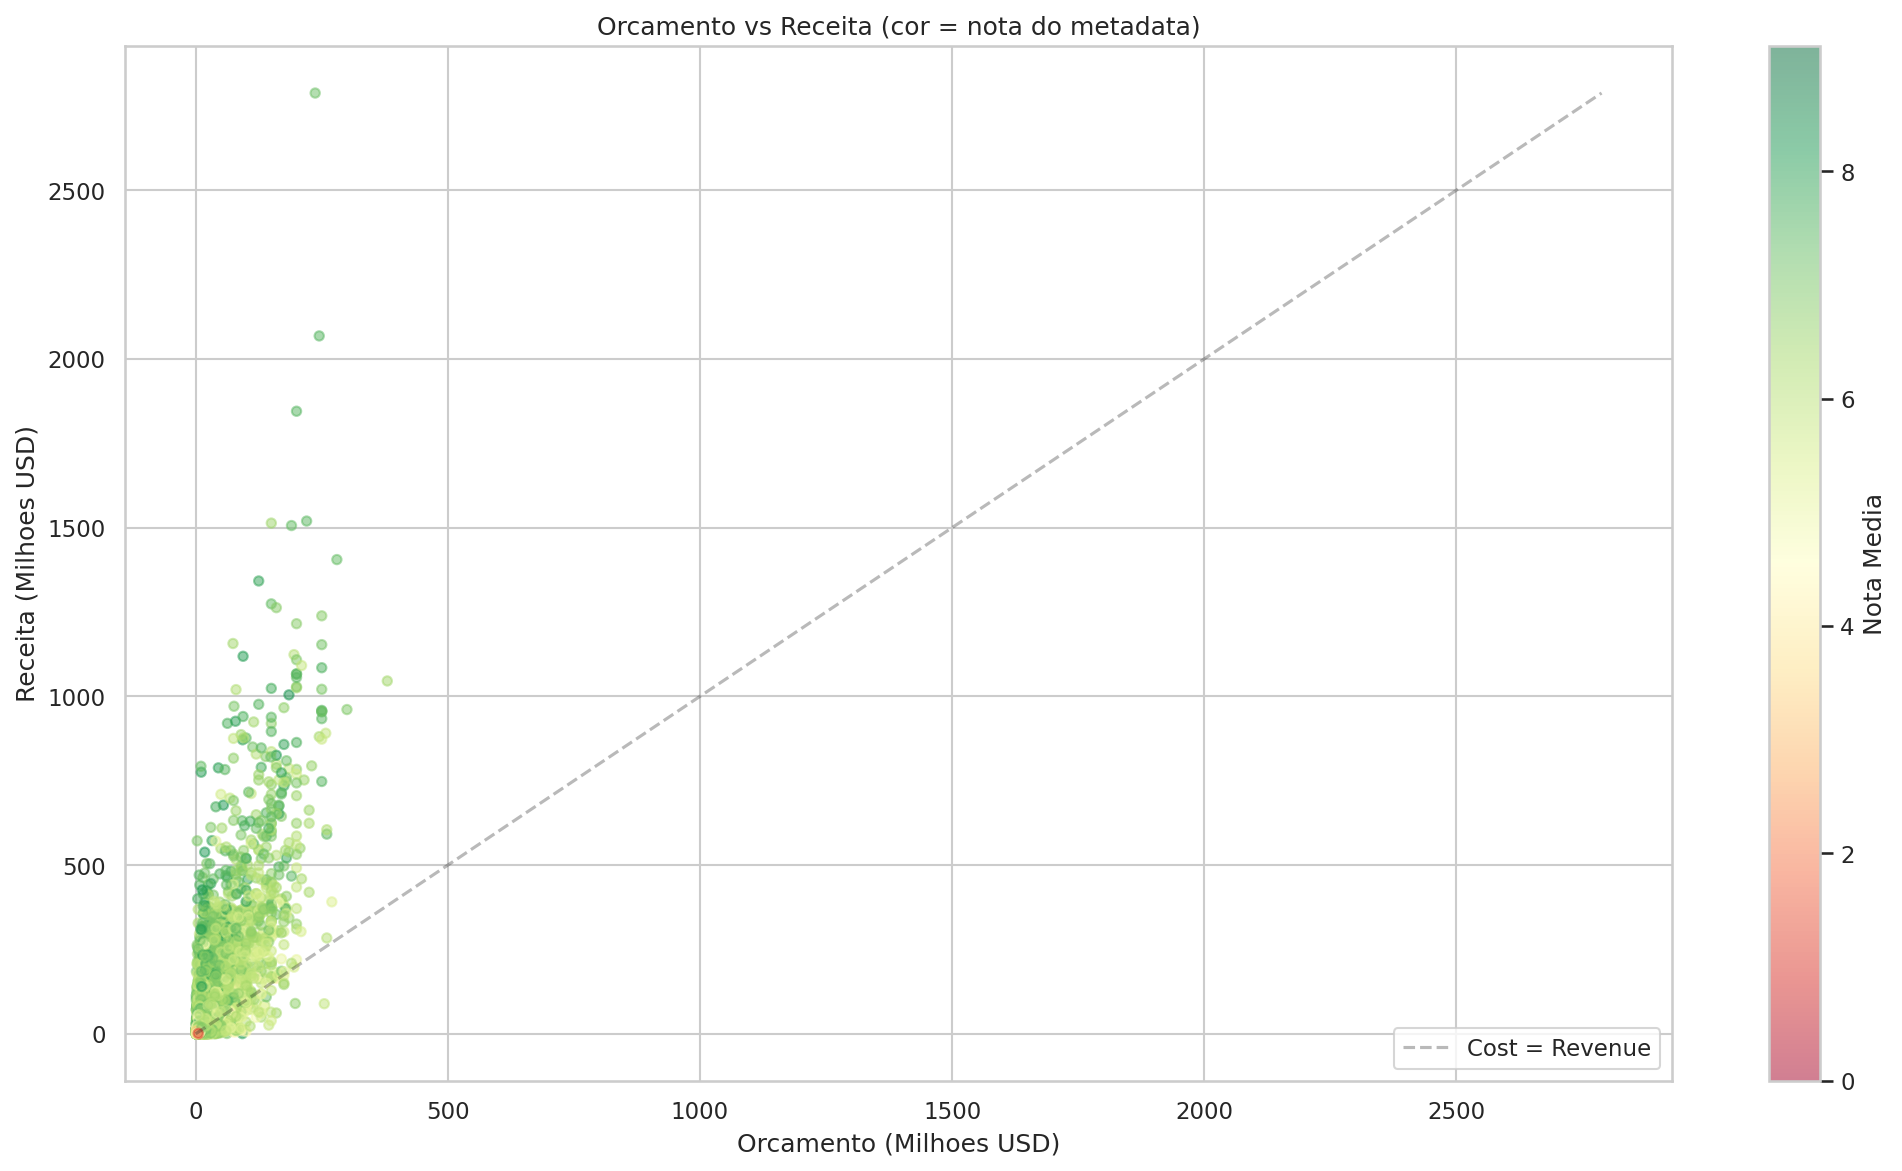

=== correlacoes_sucesso ===


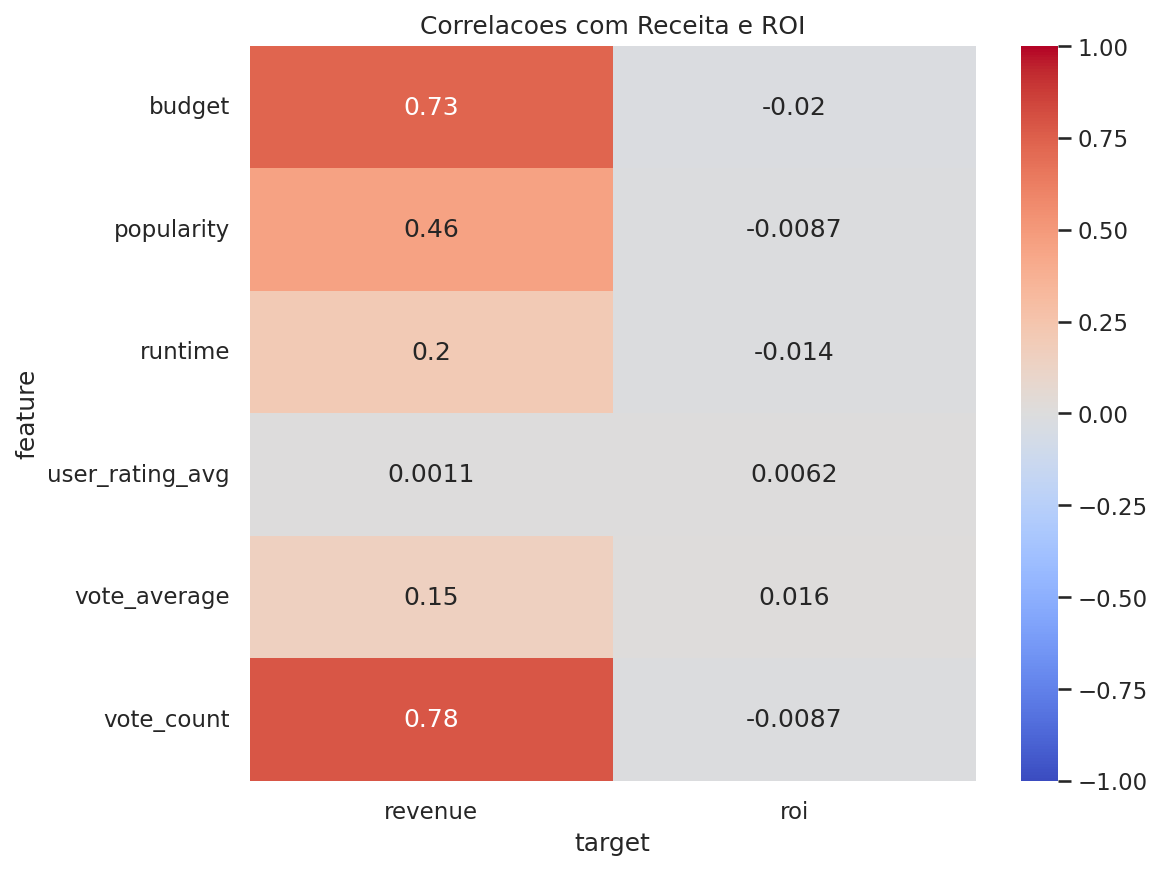

In [22]:
genre_leader = tables['receita_por_genero'].iloc[0]['primary_genre'] if not tables['receita_por_genero'].empty else None
director_leader = tables['top_diretores'].iloc[0]['director'] if not tables['top_diretores'].empty else None
busiest_decade_value = (
    tables['filmes_por_decada'].sort_values('qtd_filmes', ascending=False).iloc[0]['decade']
    if not tables['filmes_por_decada'].empty
    else None
)

highlights = {
    'genero_lider_receita': genre_leader,
    'diretor_lider_receita': director_leader,
    'decada_com_mais_filmes': safe_int(busiest_decade_value),
}

display(pd.DataFrame([highlights]))
for name, path in plot_paths.items():
    print(f'=== {name} ===')
    display(Image(filename=str(path)))
